<a href="https://www.kaggle.com/code/cartelsmith/step-by-step-building-a-neural-network?scriptVersionId=336583376" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Import Statements

In [1]:
import pandas as pd
import seaborn as sns
sns.set_theme(style='white')
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Loading Data
import kagglehub
from kagglehub import KaggleDatasetAdapter
file_path = "apple_products_pricing_2020_2026.csv"

df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "ashyou09/apple-products-pricing-dataset-2020-2026",
  file_path)

# General Dataset Info

In [2]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80000 entries, 0 to 79999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Date               80000 non-null  object 
 1   Platform           80000 non-null  object 
 2   Product_Category   80000 non-null  object 
 3   Model_Name         80000 non-null  object 
 4   Condition          80000 non-null  object 
 5   Launch_Price_USD   80000 non-null  int64  
 6   Launch_Price_INR   80000 non-null  int64  
 7   Current_Price_USD  80000 non-null  float64
 8   Current_Price_INR  80000 non-null  float64
 9   Discount_Pct       80000 non-null  float64
 10  Sale_Event         6649 non-null   object 
 11  Stock_Status       80000 non-null  object 
 12  Rating             80000 non-null  float64
 13  Reviews_Count      80000 non-null  int64  
dtypes: float64(4), int64(3), object(7)
memory usage: 8.5+ MB
None


In [3]:
display(df.head(10))

,Date,Platform,Product_Category,Model_Name,Condition,Launch_Price_USD,Launch_Price_INR,Current_Price_USD,Current_Price_INR,Discount_Pct,Sale_Event,Stock_Status,Rating,Reviews_Count
0,2020-09-19,Flipkart,Watch,Apple Watch Series 6 (44mm),New,429,42042,435.81,43322.41,-1.6,NaN,In Stock,4.7,40
1,2020-09-20,Flipkart,Watch,Apple Watch Series 6 (44mm),New,429,42042,436.49,42320.43,-1.7,NaN,Out of Stock,4.6,84
2,2020-09-23,Amazon,Watch,Apple Watch Series 6 (44mm),New,429,42042,422.73,40879.36,1.5,NaN,In Stock,4.4,110
3,2020-09-23,Amazon,Watch,Apple Watch Series 6 (44mm),New,429,42042,425.00,42008.70,0.9,NaN,In Stock,4.8,111
4,2020-09-24,Amazon,Watch,Apple Watch Series 6 (44mm),New,429,42042,436.22,41984.28,-1.7,NaN,In Stock,4.7,35
5,2020-09-26,Flipkart,Watch,Apple Watch Series 6 (44mm),New,429,42042,436.29,43149.46,-1.7,NaN,In Stock,4.7,45
6,2020-09-27,Flipkart,Watch,Apple Watch Series 6 (44mm),New,429,42042,433.06,42587.59,-0.9,NaN,In Stock,4.8,60
7,2020-09-29,Flipkart,Watch,Apple Watch Series 6 (44mm),Renewed/Refurbished,429,42042,312.11,26276.64,27.2,NaN,In Stock,4.4,146
8,2020-10-01,Flipkart,Watch,Apple Watch Series 6 (44mm),New,429,42042,323.84,31855.01,24.5,Big Billion Days,In Stock,4.7,95
9,2020-10-01,Amazon,Watch,Apple Watch Series 6 (44mm),New,429,42042,390.51,38757.36,9.0,Great Indian Festival,In Stock,4.9,133


In [4]:
drop_cols =['Launch_Price_INR','Current_Price_INR', 'Date']
df= df.drop(columns=drop_cols)
print(df.columns)

Index(['Platform', 'Product_Category', 'Model_Name', 'Condition',
       'Launch_Price_USD', 'Current_Price_USD', 'Discount_Pct', 'Sale_Event',
       'Stock_Status', 'Rating', 'Reviews_Count'],
      dtype='object')


In [5]:
# Dataframe Housekeeping

print('Unique values by column:')
display(df.nunique())    # Viewing unique values by col
to_cat_cols = [col for col in df.columns if df[col].nunique() < 5]
df[to_cat_cols] = df[to_cat_cols].astype('category') # Converting low-unique cols to 'category' dtype

print('\n\nConverted Dtypes df:')
display(df.dtypes)

Unique values by column:


Platform                 2
Product_Category         4
Model_Name              31
Condition                2
Launch_Price_USD         9
Current_Price_USD    49611
Discount_Pct           695
Sale_Event               4
Stock_Status             3
Rating                  12
Reviews_Count         8698
dtype: int64



Converted Dtypes df:


Platform             category
Product_Category     category
Model_Name             object
Condition            category
Launch_Price_USD        int64
Current_Price_USD     float64
Discount_Pct          float64
Sale_Event           category
Stock_Status         category
Rating                float64
Reviews_Count           int64
dtype: object

In [6]:
duplicates = int(df.duplicated().sum())     # Checking for Duplicate Rows
print(f"\n\nThere are {duplicates} duplicate rows in the dataframe.")



There are 0 duplicate rows in the dataframe.


# Feature Selection

In [7]:
from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import TargetEncoder, RobustScaler
from sklearn.pipeline import make_pipeline
from sklearn import set_config
set_config(transform_output="pandas")
from sklearn.compose import ColumnTransformer

X = df.copy()       # Features + Target
y = X.pop('Rating') # Removing Target col from X

print(f"\nThe shapes of 'X' and 'y', respectively, are: {X.shape}, {y.shape}.")

category_loc = df.columns.get_indexer(to_cat_cols) # Getting indicies of the categorical cols

# 🍭 I Eat Snacks (Impute, Encode, Scale) - Required for Mutual Information exploration
missing = X.isnull().sum()
print(f'\n\nMissing values per column:\n{missing}')

# 1. Imputing 'Sale_Event'
X['Sale_Event'] = X['Sale_Event'].cat.add_categories("Unknown")
X['Sale_Event'] = X['Sale_Event'].fillna('Unknown')

# 2. Encoding and Scaling X
num_cols = X.select_dtypes(include='number').columns.tolist()
cat_cols = X.select_dtypes(exclude='number').columns.tolist()

col_transformer = ColumnTransformer(transformers=[('numeric', RobustScaler(), num_cols),
                                        ('categorical', TargetEncoder(random_state=12), cat_cols)],
                          remainder='passthrough')

X_ies = col_transformer.fit_transform(X, y)

# Post-transformation sanity check
print("\n\nX_ies statistics (Post Transformation):")
display(X_ies.describe().T) 
print('👍🏽 Everything looks good!')


The shapes of 'X' and 'y', respectively, are: (80000, 10), (80000,).


Missing values per column:
Platform                 0
Product_Category         0
Model_Name               0
Condition                0
Launch_Price_USD         0
Current_Price_USD        0
Discount_Pct             0
Sale_Event           73351
Stock_Status             0
Reviews_Count            0
dtype: int64


X_ies statistics (Post Transformation):


,count,mean,std,min,25%,50%,75%,max
numeric__Launch_Price_USD,80000.0,0.274932,0.783477,-0.783333,-0.333333,0.000000,0.666667,2.000000
numeric__Current_Price_USD,80000.0,0.149285,0.830076,-1.060461,-0.479717,0.000000,0.520283,2.407897
numeric__Discount_Pct,80000.0,0.003948,0.554728,-0.774086,-0.485050,0.000000,0.514950,1.720930
numeric__Reviews_Count,80000.0,0.206070,0.793579,-0.757338,-0.401086,0.000000,0.598914,3.873140
categorical__Platform,80000.0,4.450103,0.001037,4.448595,4.449127,4.450528,4.451059,4.451721
categorical__Product_Category,80000.0,4.450098,0.001407,4.446288,4.449553,4.450438,4.451194,4.452515
categorical__Model_Name,80000.0,4.450098,0.006481,4.435070,4.445299,4.449850,4.454260,4.466145
categorical__Condition,80000.0,4.450103,0.173640,4.148195,4.150403,4.550320,4.550355,4.550728
categorical__Sale_Event,80000.0,4.450108,0.001820,4.438199,4.450303,4.450339,4.450496,4.462201
categorical__Stock_Status,80000.0,4.450096,0.001273,4.446201,4.450061,4.450371,4.450935,4.451584


👍🏽 Everything looks good!


In [8]:
mutual_inf = mutual_info_regression(X_ies,y, discrete_features=category_loc, random_state=12)

mi_features = {'Features': X_ies.columns,
               'MI_Score': mutual_inf.round(3)
               }
mi_features = pd.DataFrame(mi_features).sort_values(by='MI_Score', ascending=False).reset_index(drop=True)

,Features,MI_Score
0,numeric__Current_Price_USD,0.367
1,categorical__Condition,0.295
2,numeric__Discount_Pct,0.129
3,numeric__Reviews_Count,0.028
4,categorical__Product_Category,0.003
5,categorical__Stock_Status,0.002
6,categorical__Sale_Event,0.002
7,categorical__Model_Name,0.001
8,numeric__Launch_Price_USD,0.000
9,categorical__Platform,0.000


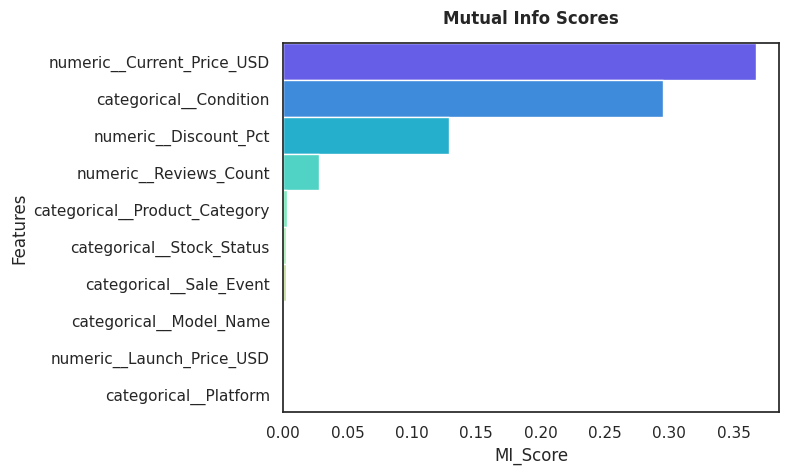

In [9]:
display(mi_features)

# Charting Features by Mutual Info Score

sns.barplot(x=mi_features['MI_Score'],y=mi_features['Features'],
            orient='h', width =1, palette= 'rainbow')

plt.title("Mutual Info Scores", pad = 14, fontweight='bold', fontsize=12)
plt.show()

# Selecting only the features that have a MI Score > .001
modeling_feats = [feat for feat, score in zip(mi_features['Features'], mi_features['MI_Score']) if score > 0.01]

# Dropping prefix from column name
modeling_feats_clean = [col.split('__', 1)[-1] for col in modeling_feats]

# Feature Review

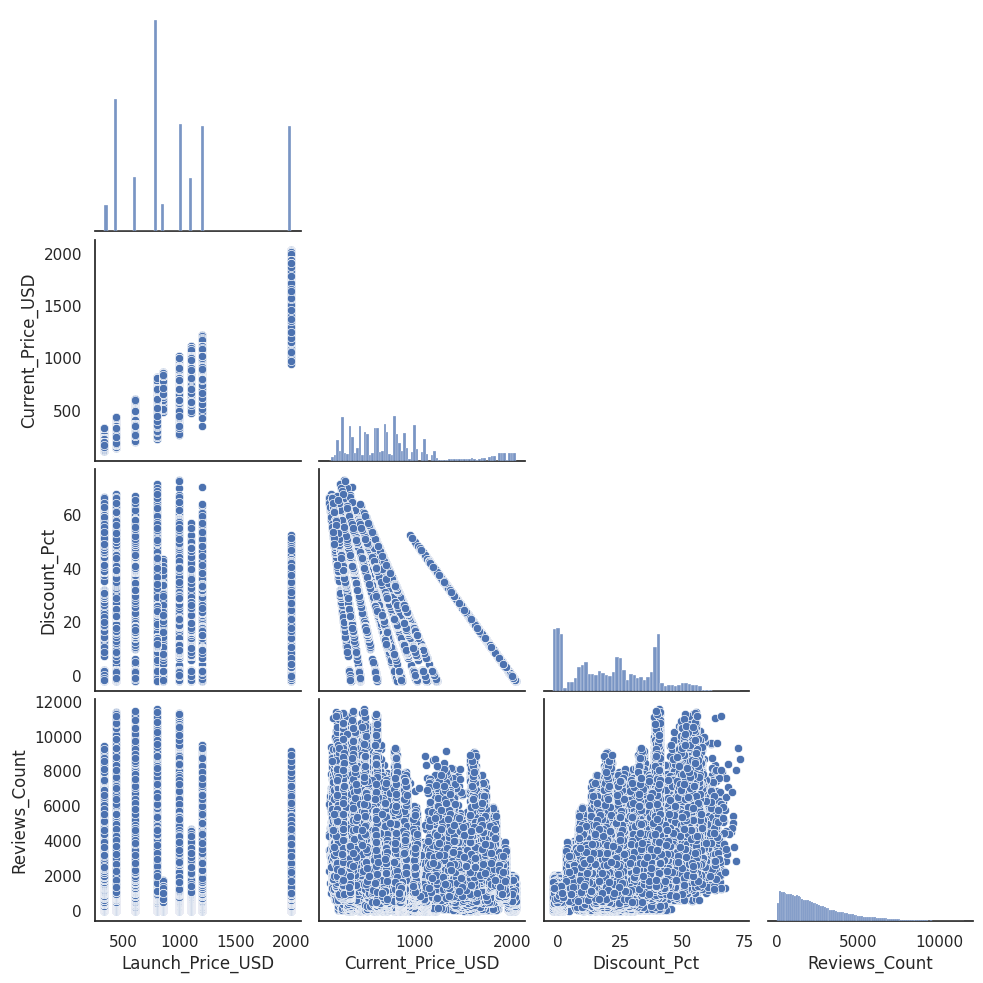

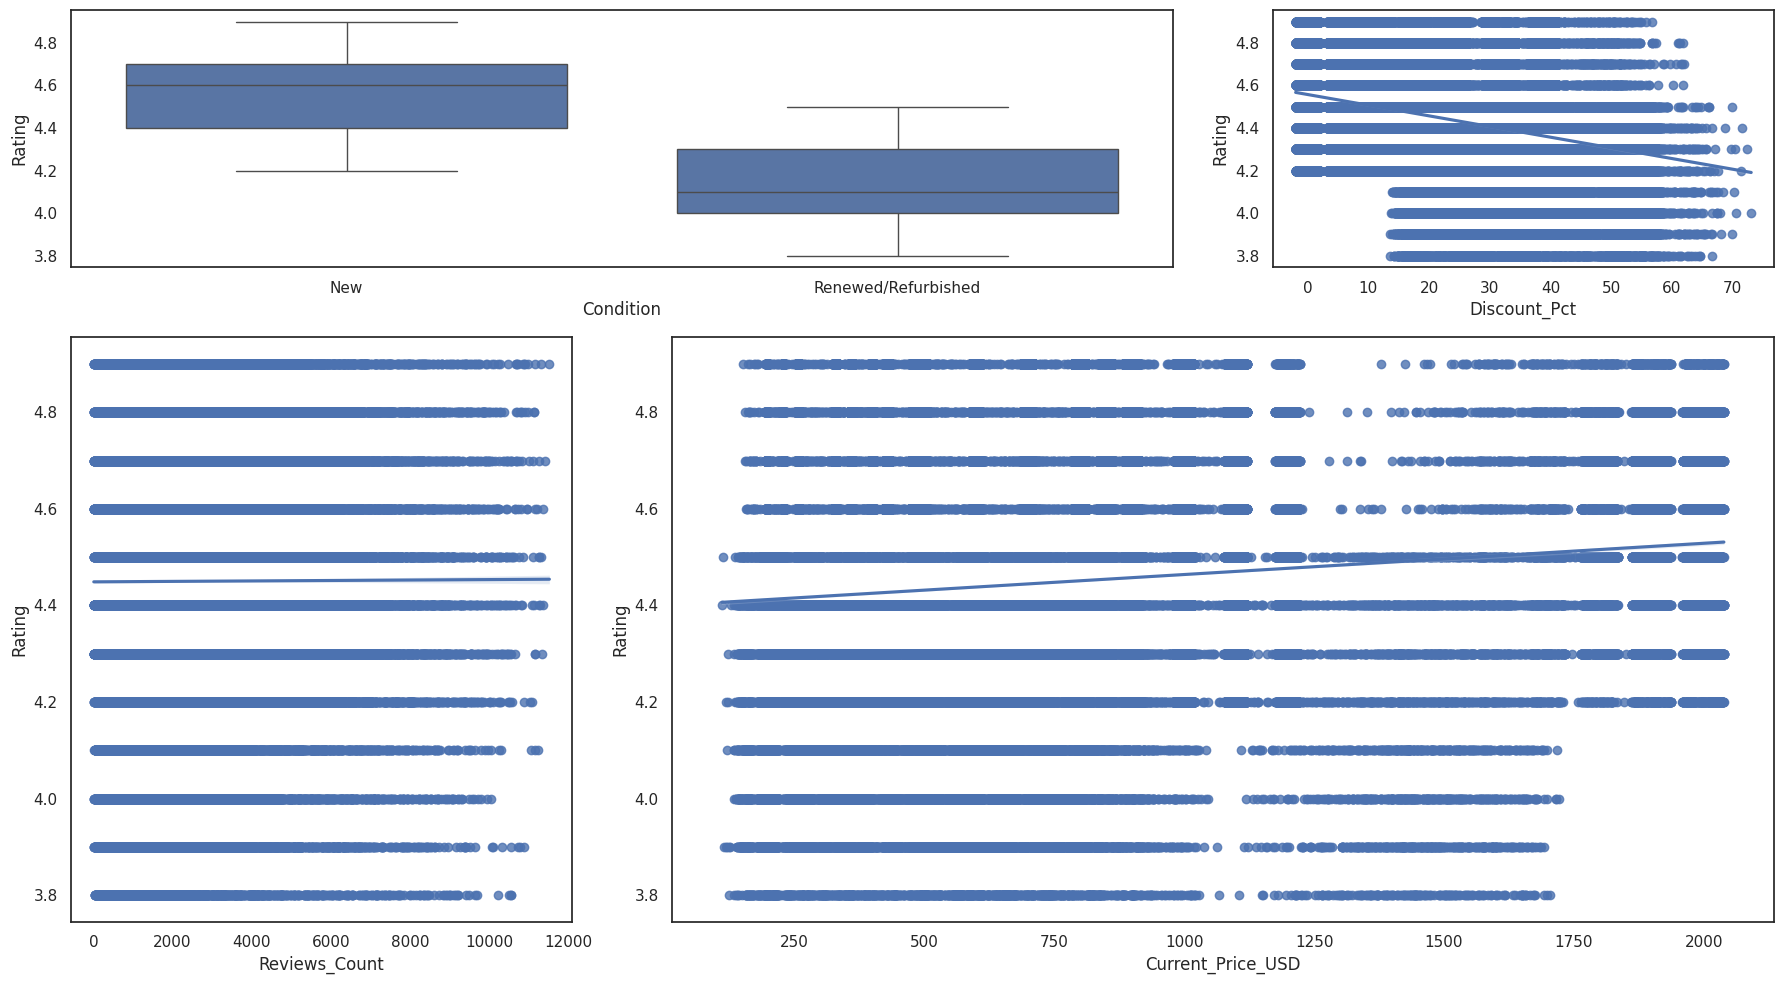

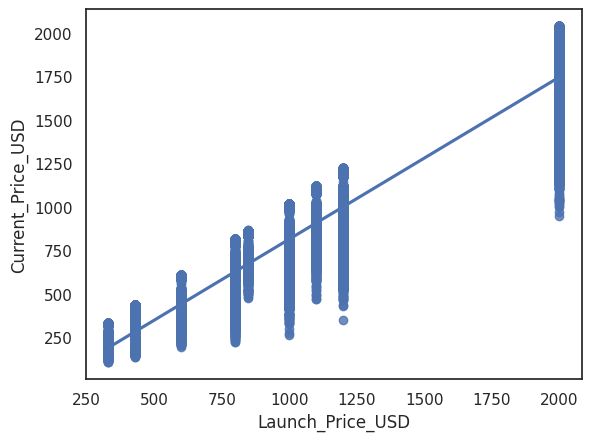

In [10]:
# Viewing Selected Features 
sns.pairplot(X, corner=True)

mosaic = [['A', 'A', 'B'],
          ['D', 'C','C'],
          ['D', 'C','C']
         ]

fig, axes = plt.subplot_mosaic(mosaic=mosaic, figsize=(18,10))
sns.boxplot(x=X.Condition, y=y, ax=axes['A']);
sns.regplot(x=X.Current_Price_USD, y=y, ax=axes['C'])
sns.regplot(x=X.Discount_Pct, y=y, ax=axes['B'])
sns.regplot(x=X.Reviews_Count, y=y, ax=axes['D'])
plt.tight_layout()
plt.show()

sns.regplot(x=X.Launch_Price_USD, y=X.Current_Price_USD);

# Train Test Split

In [11]:
from sklearn.model_selection import train_test_split

Xtrain,Xtest,ytrain,ytest = train_test_split(X_ies[modeling_feats], y, train_size=.75, random_state=12)

# ***Model Architecture***
  

In [12]:
from keras.layers import Dense
from keras.models import Sequential
from keras.callbacks import EarlyStopping
from keras.utils import set_random_seed
set_random_seed(12)

model = Sequential([Dense(4,activation='relu',input_shape=(4,)),
                    Dense(2,activation='relu'),
                    Dense(1,activation='linear')])

model.compile(optimizer='adam',
              loss='mse',
              metrics=['mae'])

# View Model
print(model.summary())

I0000 00:00:1784511330.838288      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 4)              │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │            10 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33 (132.00 B)

 Trainable params: 33 (132.00 B)

 Non-trainable params: 0 (0.00 B)

None


# ***Model Evaluation***

In [13]:
# 1. Define the Early Stopping rule
early_stopping = EarlyStopping(
    monitor='val_loss',          # metric to watch
    patience=7,                 # How many epochs to wait before stopping
    restore_best_weights=True    # Roll back to the best weights if stopped
)

# 2. Fit model and pass Early Stopping to callbacks
history = model.fit(x= Xtrain, y=ytrain,
                    batch_size=64, epochs=300,
                    validation_data=(Xtest, ytest),
                    callbacks=[early_stopping],        
                    )

Epoch 1/300
 73/938 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 19.7098 - mae: 4.4316

I0000 00:00:1784511333.904570     131 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 16.1101 - mae: 3.9963 - val_loss: 12.7290 - val_mae: 3.5576
Epoch 2/300
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 10.0220 - mae: 3.1456 - val_loss: 7.6224 - val_mae: 2.7477
Epoch 3/300
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 5.7545 - mae: 2.3742 - val_loss: 4.1320 - val_mae: 2.0148
Epoch 4/300
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 2.9345 - mae: 1.6812 - val_loss: 1.9317 - val_mae: 1.3635
Epoch 5/300
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 1.2589 - mae: 1.0773 - val_loss: 0.7309 - val_mae: 0.8114
Epoch 6/300
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.4324 - mae: 0.5932 - val_loss: 0.2241 - val_mae: 0.4140
Epoch 7/300
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.1380 - mae: 0.3097 - val_loss: 0.0892 - val_mae: 0.2444
Epoch 8/300
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0779 - mae: 0.2278 - val_loss: 0.0731 - val_mae: 0.2220
Epoch 9/300
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - lo

In [14]:
results = pd.DataFrame(history.history) # Results Dataframe

display(results.head())
print('\n\n')
print(results.info())

,loss,mae,val_loss,val_mae
0,16.110050,3.996341,12.729016,3.557589
1,10.022006,3.145556,7.622422,2.747696
2,5.754510,2.374215,4.132036,2.014807
3,2.934520,1.681155,1.931707,1.363498
4,1.258896,1.077299,0.730890,0.811361





<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17 entries, 0 to 16
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   loss      17 non-null     float64
 1   mae       17 non-null     float64
 2   val_loss  17 non-null     float64
 3   val_mae   17 non-null     float64
dtypes: float64(4)
memory usage: 676.0 bytes
None


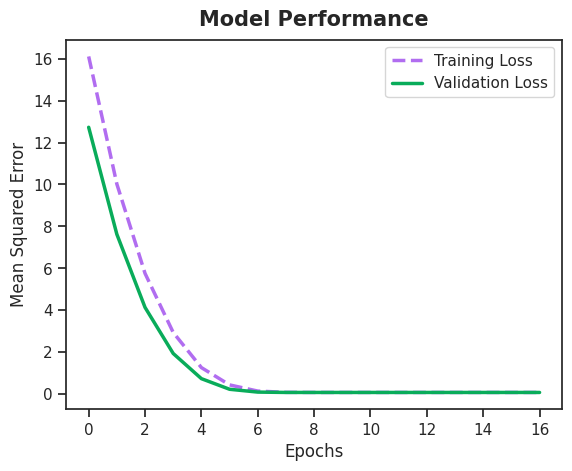

In [15]:
train_loss = results['loss']
val_loss = results['val_loss']

# Charting Model Training 
sns.set_style('ticks')
sns.lineplot(x=results.index, y =train_loss, label ='Training Loss', ls ="dashed", lw=2.5, color="#963aecbd")
sns.lineplot(x=results.index, y =val_loss, label ='Validation Loss', lw =2.5, color = "#09ac5aff")

plt.title('Model Performance', pad=10, fontweight ='bold', fontsize= 15)
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error')
#plt.ylim(0,10)
plt.show()